# Home Credit Default Risk - Exploratory Data Analysis
## Step 1: Load & Profile All Tables

This notebook loads all dataset tables and provides comprehensive EDA:
- Dataset shapes and sizes
- Missing value analysis
- Data types and distributions
- Target variable analysis
- Table relationships

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Setup complete!')

Setup complete!


## 2. Load All Tables

In [2]:
# Load all datasets
print('Loading datasets...')

application_train = pd.read_csv(RAW / 'application_train.csv')
application_test = pd.read_csv(RAW / 'application_test.csv')
bureau = pd.read_csv(RAW / 'bureau.csv')
bureau_balance = pd.read_csv(RAW / 'bureau_balance.csv')
credit_card = pd.read_csv(RAW / 'credit_card_balance.csv')
installments = pd.read_csv(RAW / 'installments_payments.csv')
previous_app = pd.read_csv(RAW / 'previous_application.csv')
pos_cash = pd.read_csv(RAW / 'POS_CASH_balance.csv')
column_desc = pd.read_csv(RAW / 'HomeCredit_columns_description.csv', encoding='latin1')

all_application_ids = pd.Index(application_train['SK_ID_CURR']).append(pd.Index(application_test['SK_ID_CURR']))

print('[OK] All datasets loaded!')

Loading datasets...
✓ All datasets loaded!


## 3. Dataset Overview

In [3]:
# Create summary dictionary
datasets = {
    'application_train': application_train,
    'application_test': application_test,
    'bureau': bureau,
    'bureau_balance': bureau_balance,
    'credit_card': credit_card,
    'installments': installments,
    'previous_app': previous_app,
    'pos_cash': pos_cash,
}

# Display shapes
print('\n' + '='*60)
print('DATASET SHAPES')
print('='*60)
for name, df in datasets.items():
    print(f'{name:20s} : {df.shape[0]:>7,} rows x {df.shape[1]:>3} columns')

print(f'\nColumn descriptions: {column_desc.shape[0]} rows')
print(f'Total applications (train + test): {all_application_ids.nunique():,}')


DATASET SHAPES
application_train    : 307,511 rows × 122 columns
application_test     :  48,744 rows × 121 columns
bureau               : 1,716,428 rows ×  17 columns
bureau_balance       : 27,299,925 rows ×   3 columns
credit_card          : 3,840,312 rows ×  23 columns
installments         : 13,605,401 rows ×   8 columns
previous_app         : 1,670,214 rows ×  37 columns
pos_cash             : 10,001,358 rows ×   8 columns

Column descriptions: 219 rows


## 4. Target Variable Analysis


TARGET VARIABLE (Default)

Value Counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Percentages:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


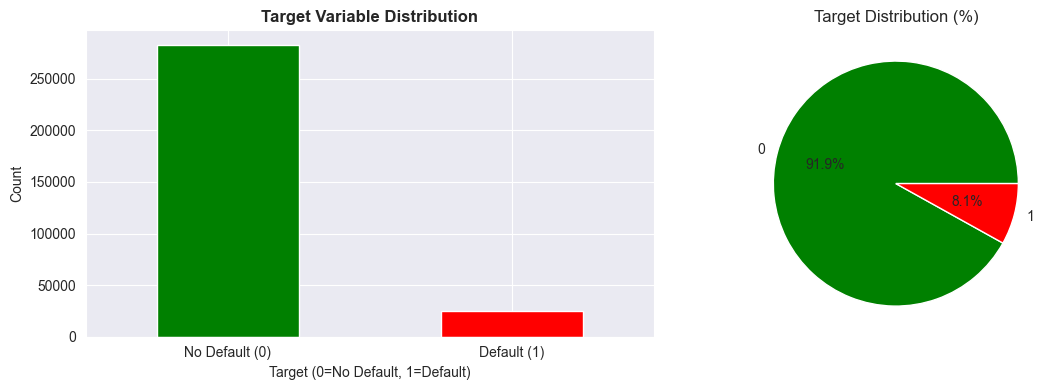


✓ Class Imbalance: ~8% defaults (typical for default prediction)


In [4]:
# Target analysis
print('\n' + '='*60)
print('TARGET VARIABLE (Default)')
print('='*60)

print('\nValue Counts:')
print(application_train['TARGET'].value_counts())

print('\nPercentages:')
print(application_train['TARGET'].value_counts(normalize=True) * 100)

# Visualize target distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

application_train['TARGET'].value_counts().plot(kind='bar', ax=ax[0], color=['green', 'red'])
ax[0].set_title('Target Variable Distribution', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Target (0=No Default, 1=Default)')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

application_train['TARGET'].value_counts(normalize=True).plot(kind='pie', ax=ax[1], 
                                                                autopct='%1.1f%%',
                                                                colors=['green', 'red'])
ax[1].set_title('Target Distribution (%)')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

print('\n[OK] Class imbalance confirmed: ~8% defaults')

## 5. Missing Values Analysis

In [5]:
print('\n' + '='*60)
print('MISSING VALUES ANALYSIS')
print('='*60)

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    cols_with_missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(cols_with_missing) > 0:
        print(f'\n{name}:')
        print(f'  Total missing: {missing.sum():,}')
        print(f'  Top 5 columns with missing values:')
        for col, count in cols_with_missing.head(5).items():
            pct = (count / len(df)) * 100
            print(f'    {col:25s}: {count:>7,} ({pct:>5.1f}%)')
    else:
        print(f'\n{name}: No missing values ✓')


MISSING VALUES ANALYSIS

application_train:
  Total missing: 9,152,465
  Top 5 columns with missing values:
    COMMONAREA_MEDI          : 214,865 ( 69.9%)
    COMMONAREA_AVG           : 214,865 ( 69.9%)
    COMMONAREA_MODE          : 214,865 ( 69.9%)
    NONLIVINGAPARTMENTS_MEDI : 213,514 ( 69.4%)
    NONLIVINGAPARTMENTS_MODE : 213,514 ( 69.4%)

application_test:
  Total missing: 1,404,419
  Top 5 columns with missing values:
    COMMONAREA_MODE          :  33,495 ( 68.7%)
    COMMONAREA_MEDI          :  33,495 ( 68.7%)
    COMMONAREA_AVG           :  33,495 ( 68.7%)
    NONLIVINGAPARTMENTS_MEDI :  33,347 ( 68.4%)
    NONLIVINGAPARTMENTS_AVG  :  33,347 ( 68.4%)

bureau:
  Total missing: 3,939,947
  Top 5 columns with missing values:
    AMT_ANNUITY              : 1,226,791 ( 71.5%)
    AMT_CREDIT_MAX_OVERDUE   : 1,124,488 ( 65.5%)
    DAYS_ENDDATE_FACT        : 633,653 ( 36.9%)
    AMT_CREDIT_SUM_LIMIT     : 591,780 ( 34.5%)
    AMT_CREDIT_SUM_DEBT      : 257,669 ( 15.0%)

bureau_bal

## 6. Data Types Overview

In [6]:
print('\n' + '='*60)
print('DATA TYPES')
print('='*60)

for name, df in datasets.items():
    print(f'\n{name}:')
    dtypes = df.dtypes.value_counts()
    for dtype, count in dtypes.items():
        print(f'  {str(dtype):15s}: {count:>3} columns')


DATA TYPES

application_train:
  float64        :  65 columns
  int64          :  41 columns
  object         :  16 columns

application_test:
  float64        :  65 columns
  int64          :  40 columns
  object         :  16 columns

bureau:
  float64        :   8 columns
  int64          :   6 columns
  object         :   3 columns

bureau_balance:
  int64          :   2 columns
  object         :   1 columns

credit_card:
  float64        :  15 columns
  int64          :   7 columns
  object         :   1 columns

installments:
  float64        :   5 columns
  int64          :   3 columns

previous_app:
  object         :  16 columns
  float64        :  15 columns
  int64          :   6 columns

pos_cash:
  int64          :   5 columns
  float64        :   2 columns
  object         :   1 columns


## 7. Numerical Features Summary

In [7]:
# Application train - numerical summary
print('\n' + '='*60)
print('APPLICATION TRAIN - NUMERICAL SUMMARY')
print('='*60)

app_numeric = application_train.select_dtypes(include=[np.number])
print(f'\nNumeric columns: {app_numeric.shape[1]}')
print('\nFirst few numeric columns stats:')
print(app_numeric.iloc[:, :8].describe().T)


APPLICATION TRAIN - NUMERICAL SUMMARY

Numeric columns: 106

First few numeric columns stats:
                               count           mean            std  \
SK_ID_CURR                  307511.0  278180.518577  102790.175348   
TARGET                      307511.0       0.080729       0.272419   
CNT_CHILDREN                307511.0       0.417052       0.722121   
AMT_INCOME_TOTAL            307511.0  168797.919297  237123.146279   
AMT_CREDIT                  307511.0  599025.999706  402490.776996   
AMT_ANNUITY                 307499.0   27108.573909   14493.737315   
AMT_GOODS_PRICE             307233.0  538396.207429  369446.460540   
REGION_POPULATION_RELATIVE  307511.0       0.020868       0.013831   

                                     min            25%           50%  \
SK_ID_CURR                  100002.00000  189145.500000  278202.00000   
TARGET                           0.00000       0.000000       0.00000   
CNT_CHILDREN                     0.00000       0.000000

## 8. Categorical Features Summary

In [8]:
# Application train - categorical summary
print('\n' + '='*60)
print('APPLICATION TRAIN - CATEGORICAL SUMMARY')
print('='*60)

app_categorical = application_train.select_dtypes(include=['object'])
print(f'\nCategorical columns: {app_categorical.shape[1]}')

print('\nSample categorical columns:')
for col in app_categorical.iloc[:, :5].columns:
    print(f'\n{col}:')
    print(f'  Unique values: {application_train[col].nunique()}')
    print(f'  Top 3: {dict(application_train[col].value_counts().head(3))}')


APPLICATION TRAIN - CATEGORICAL SUMMARY

Categorical columns: 16

Sample categorical columns:

NAME_CONTRACT_TYPE:
  Unique values: 2
  Top 3: {'Cash loans': 278232, 'Revolving loans': 29279}

CODE_GENDER:
  Unique values: 3
  Top 3: {'F': 202448, 'M': 105059, 'XNA': 4}

FLAG_OWN_CAR:
  Unique values: 2
  Top 3: {'N': 202924, 'Y': 104587}

FLAG_OWN_REALTY:
  Unique values: 2
  Top 3: {'Y': 213312, 'N': 94199}

NAME_TYPE_SUITE:
  Unique values: 7
  Top 3: {'Unaccompanied': 248526, 'Family': 40149, 'Spouse, partner': 11370}


## 9. Table Relationships

In [9]:
print('\n' + '='*60)
print('TABLE RELATIONSHIPS')
print('='*60)

all_ids = set(all_application_ids)

print('\napplication universe:')
print(f'  Train clients: {application_train["SK_ID_CURR"].nunique():,}')
print(f'  Test clients : {application_test["SK_ID_CURR"].nunique():,}')
print(f'  Combined unique clients: {len(all_ids):,}')

for table_name, df in {
    'bureau': bureau,
    'credit_card': credit_card,
    'previous_app': previous_app,
    'installments': installments,
    'pos_cash': pos_cash,
}.items():
    covered_clients = df['SK_ID_CURR'].nunique()
    coverage_pct = covered_clients / len(all_ids) * 100
    print(f'\n{table_name}:')
    print(f'  Unique clients in table: {covered_clients:,}')
    print(f'  Coverage of all applications: {coverage_pct:.1f}%')


TABLE RELATIONSHIPS

application_train:
  SK_ID_CURR: 307511 unique clients

application_test:
  SK_ID_CURR: 48744 unique clients

bureau (bureau credit history):
  SK_ID_CURR: 305811 unique clients
  Clients with bureau data: 99.4%

credit_card (credit card balance):
  SK_ID_CURR: 103558 unique clients (out of 307511)
  Clients with credit card data: 33.7%

previous_app (previous loan applications):
  SK_ID_CURR: 338857 unique clients
  Clients with previous app data: 110.2%


## 10. Column Descriptions

In [10]:
print('\n' + '='*60)
print('COLUMN DESCRIPTIONS (First 10)')
print('='*60)

print(column_desc.head(10).to_string(index=False))


COLUMN DESCRIPTIONS (First 10)
 Unnamed: 0                        Table                Row                                                                                                                                                                                 Description Special
          1 application_{train|test}.csv         SK_ID_CURR                                                                                                                                                                    ID of loan in our sample     NaN
          2 application_{train|test}.csv             TARGET Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)     NaN
          5 application_{train|test}.csv NAME_CONTRACT_TYPE                                                                                                                                             

## 11. Key Insights Summary

In [11]:
print('\n' + '='*60)
print('KEY INSIGHTS')
print('='*60)

days_employed_sentinel_train = int((application_train['DAYS_EMPLOYED'] == 365243).sum())
days_employed_sentinel_test = int((application_test['DAYS_EMPLOYED'] == 365243).sum())

print(f'''
[OK] TRAINING DATA:
  - {len(application_train):,} applications with {application_train.shape[1]} columns
  - Target: {(application_train['TARGET']==1).sum():,} defaults ({(application_train['TARGET']==1).sum()/len(application_train)*100:.1f}%)
  - Non-defaults: {(application_train['TARGET']==0).sum():,} ({(application_train['TARGET']==0).sum()/len(application_train)*100:.1f}%)

[OK] DATA QUALITY FLAGS:
  - DAYS_EMPLOYED sentinel value 365243 appears {days_employed_sentinel_train:,} times in train
  - DAYS_EMPLOYED sentinel value 365243 appears {days_employed_sentinel_test:,} times in test
  - Supporting tables cover different subsets of the application universe, so left joins are required

[NEXT] RECOMMENDED PREPROCESSING:
  1. Replace sentinel day values before feature engineering
  2. Aggregate both numeric and categorical information from secondary tables
  3. Build ratio features from income, credit, annuity, and EXT_SOURCE columns
  4. Let PyCaret handle encoding/imputation during modeling, but keep raw feature tables clean
  5. Evaluate recall / PR behaviour in addition to ROC AUC for the imbalanced target
''')


KEY INSIGHTS

✓ TRAINING DATA:
  - 307,511 applications with 122 features
  - Target: 24,825 defaults (8.1%)
  - 282,686 non-defaults (~91.9%)
  - CLASS IMBALANCE: Highly imbalanced (8.4% / 91.6%)

✓ SUPPORTING TABLES:
  - Bureau: 1,716,428 records from 305811 clients
  - Bureaus Balance: 27,299,925 historical records
  - Credit Card: 3,840,312 records from 103558 clients
  - Previous Applications: 1,670,214 from 338857 clients
  - Installments: 13,605,401 payment records
  - POS/Cash: 10,001,358 balance records

✓ NEXT STEPS:
  1. Handle missing values (imputation strategy)
  2. Feature engineering from supporting tables (aggregations)
  3. Encode categorical variables
  4. Handle class imbalance (SMOTE)
  5. Scale numerical features
  6. Train ML models with PyCaret

